## Stereo Camera Calibration

In [26]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from tqdm.notebook import tqdm  # notebook version for better progress bar
import time

In [27]:
### STEP 1. =============== Configuration Setup ==================
#CHECKERBOARD: (columns, rows) of inner corners  
#square_size: Physical size of squares in meters (critical for real-world measurements)

# ========== USER CONFIGURATION ==========
CHECKERBOARD = (7, 9)        # Inner corners (columns, rows)
square_size = 0.015          # Physical size per square in meters (15mm per square)
MIN_CALIB_PAIRS = 10  # Minimum valid pairs required
PREVIEW_SIZE = (800, 600)    # Size for visualization previews
# ========================================

In [28]:
### STEP 2. =============== Preprocessing Image ====================
# Adaptive image enhancement function
# This function enhances the checkerboard images for better corner detection
# It includes sharpening, CLAHE (Contrast Limited Adaptive Histogram Equalization), and denoising
# The parameters can be adjusted to suit different lighting conditions and image qualities

def enhance_checkerboard(img, 
                        sharp_strength=2.0, 
                        clahe_clip=3.0, 
                        denoise_h=5):
    """
    Three-stage image enhancement:
    1. Sharpening: Boost edge contrast
    2. CLAHE: Improve local contrast
    3. Denoising: Reduce grain while preserving edges
    """
    # Convert to grayscale (single channel processing)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Stage 1: Sharpening using unsharp masking
    blurred = cv2.GaussianBlur(gray, (0, 0), 2.5)
    sharpened = cv2.addWeighted(gray, sharp_strength, blurred, -1.0, 0)
    
    # Stage 2: Contrast Limited Adaptive Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(sharpened)
    
    # Stage 3: Edge-preserving denoising
    denoised = cv2.fastNlMeansDenoising(contrast_enhanced, 
                                      h=denoise_h,
                                      templateWindowSize=5,
                                      searchWindowSize=15)
    return gray, contrast_enhanced, denoised

In [29]:
### STEP 3. =============== Data Loading & Validation ====================
# Load stereo image pairs from specified directories
# Ensure left and right images are in separate folders
# and sorted correctly for calibration

left_images = sorted(glob.glob('calibration_photos/left/*.jpg'))
right_images = sorted(glob.glob('calibration_photos/right/*.jpg'))

# Pair validation check
if len(left_images) != len(right_images):
    raise ValueError(f"Pair mismatch: {len(left_images)} left vs {len(right_images)} right images")

print(f"Loaded {len(left_images)} stereo pairs")
print("Sample left images:", left_images[:3])
print("Sample right images:", right_images[:3])

Loaded 44 stereo pairs
Sample left images: ['calibration_photos/left/left_0.jpg', 'calibration_photos/left/left_1.jpg', 'calibration_photos/left/left_10.jpg']
Sample right images: ['calibration_photos/right/right_0.jpg', 'calibration_photos/right/right_1.jpg', 'calibration_photos/right/right_10.jpg']


In [30]:
### STEP 4. =============== Calibration Pattern Initialization ====================
# 3D world coordinates setup
# Generate 3D world points (Z=0 for planar board)
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2) * square_size

# Storage for calibration correspondences
objpoints = []     # 3D world points
imgpoints_left = []  # 2D left image points
imgpoints_right = [] # 2D right image points

Processing Pairs:   0%|          | 0/44 [00:00<?, ?it/s]

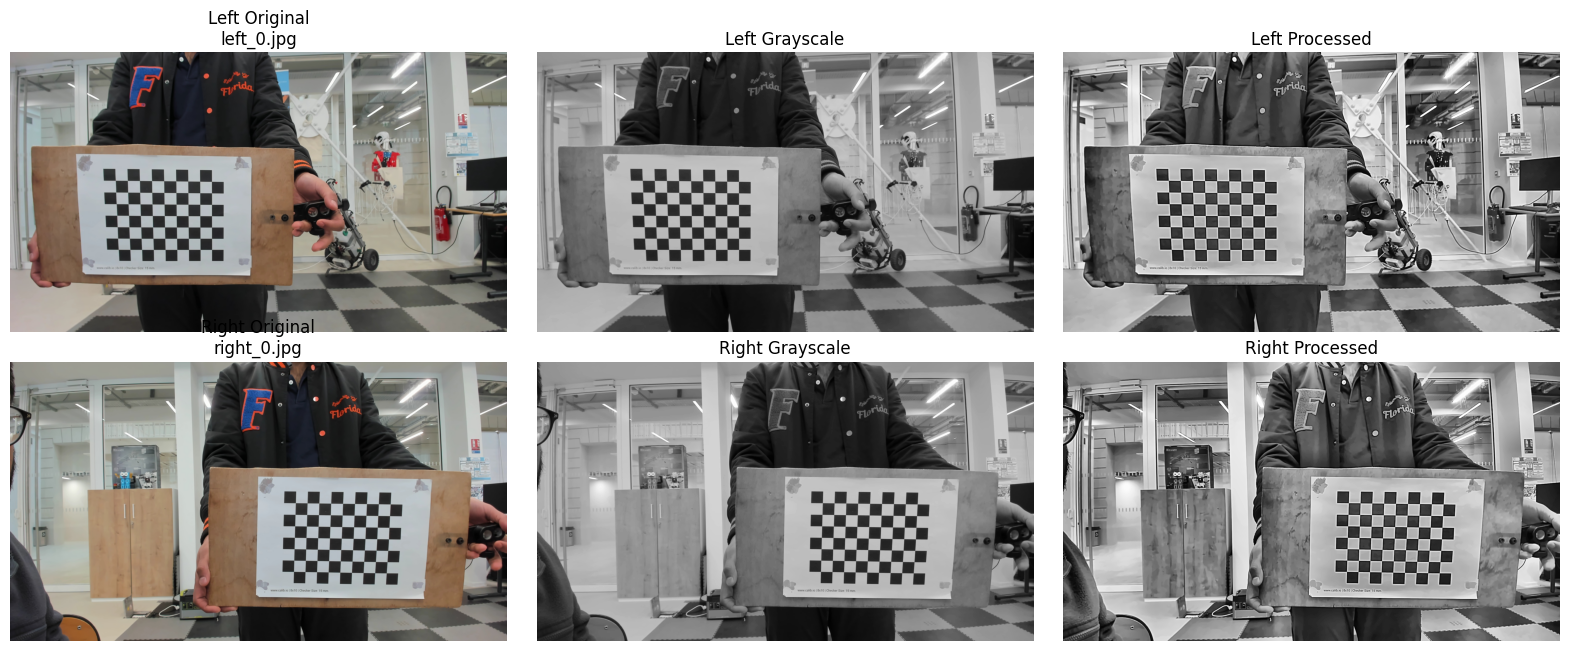

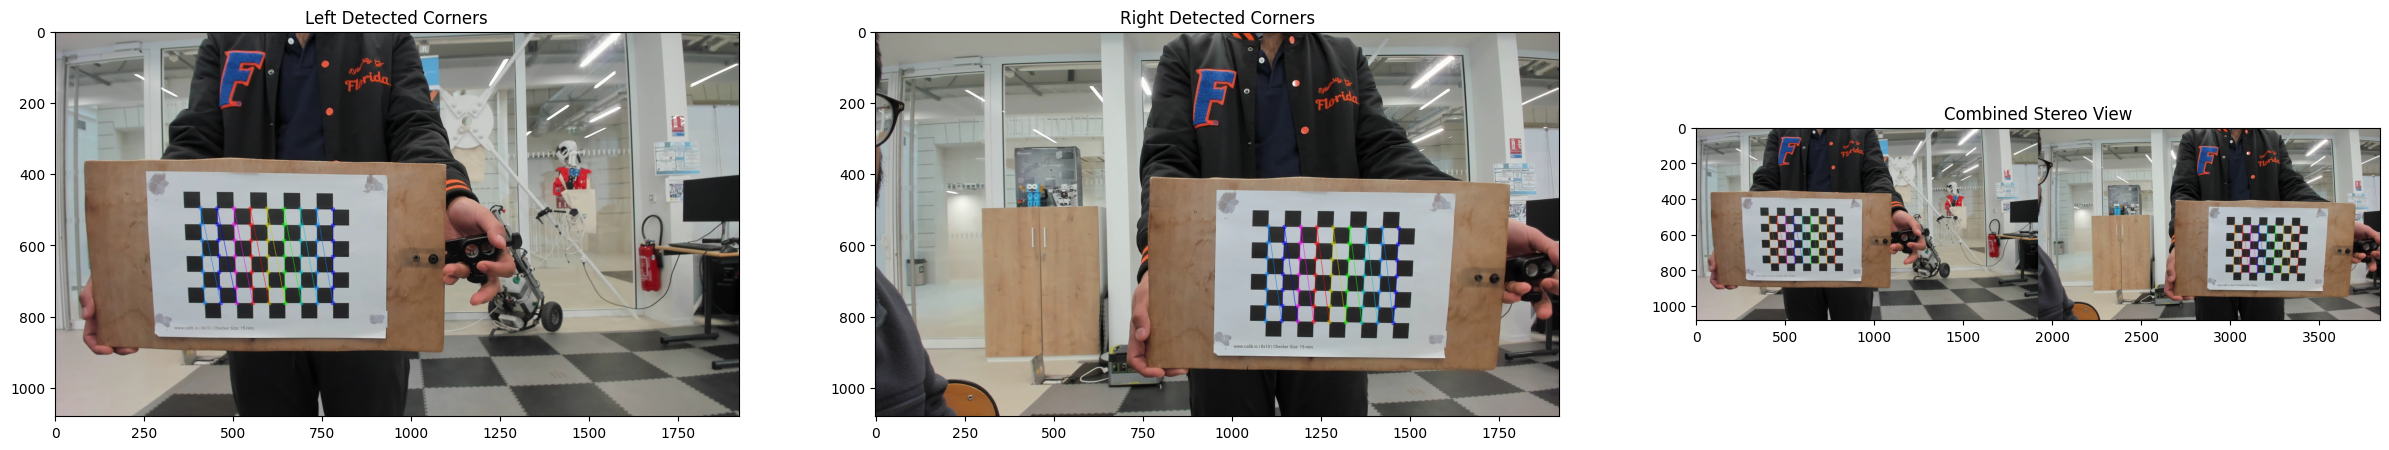


⚠️ Skipping pair 21: Corners not detected in both images

⚠️ Skipping pair 23: Corners not detected in both images

⏱️ Calibration preparation took 39.68 seconds.


In [31]:
### STEP 5. =============== Processing Loop and Corner Detection ====================
# Shows Original -> Grayscale -> Final Preprocessed (plots only for a few images to save time)

plt.ioff()  # Disable interactive mode for controlled visualization
start_time = time.time()

NUM_IMAGES_TO_VISUALIZE = 1  # Set to 0 to disable visualization completely
SHOW_ALL_IMAGES = False     # If True, ignores above and shows everything

for pair_num, (left_path, right_path) in enumerate(tqdm(zip(left_images, right_images), total=len(left_images), desc="Processing Pairs")):
    # Load image pair
    img_left = cv2.imread(left_path)
    img_right = cv2.imread(right_path)

    # Preprocess
    gray_l, _, proc_l = enhance_checkerboard(img_left)
    gray_r, _, proc_r = enhance_checkerboard(img_right)

    # ========= Controlled Visualization =========
    if SHOW_ALL_IMAGES or (NUM_IMAGES_TO_VISUALIZE > 0 and pair_num < NUM_IMAGES_TO_VISUALIZE):
        fig = plt.figure(figsize=(20, 10))
        grid = ImageGrid(fig, 111, nrows_ncols=(2, 3), axes_pad=0.3)
        
        # Left Camera
        grid[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
        grid[0].set_title(f"Left Original\n{left_path.split('/')[-1]}")
        grid[1].imshow(gray_l, cmap='gray')
        grid[1].set_title("Left Grayscale")
        grid[2].imshow(proc_l, cmap='gray')
        grid[2].set_title("Left Processed")

        # Right Camera
        grid[3].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
        grid[3].set_title(f"Right Original\n{right_path.split('/')[-1]}")
        grid[4].imshow(gray_r, cmap='gray')
        grid[4].set_title("Right Grayscale")
        grid[5].imshow(proc_r, cmap='gray')
        grid[5].set_title("Right Processed")

        for ax in grid:
            ax.axis('off')
        plt.show()

    # ========== CORNER DETECTION & VALIDATION ==========
    ret_l, corners_l = cv2.findChessboardCorners(proc_l, CHECKERBOARD, None)
    ret_r, corners_r = cv2.findChessboardCorners(proc_r, CHECKERBOARD, None)

    if ret_l and ret_r:
        # Refine corner positions
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners_l = cv2.cornerSubPix(proc_l, corners_l, (11,11), (-1,-1), criteria)
        corners_r = cv2.cornerSubPix(proc_r, corners_r, (11,11), (-1,-1), criteria)

        # Store correspondences
        objpoints.append(objp)
        imgpoints_left.append(corners_l)
        imgpoints_right.append(corners_r)

        # ========= Optional Corner Visualization =========
        if SHOW_ALL_IMAGES or (NUM_IMAGES_TO_VISUALIZE > 0 and pair_num < NUM_IMAGES_TO_VISUALIZE):
            fig, ax = plt.subplots(1, 3, figsize=(30, 10))
            
            disp_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)
            cv2.drawChessboardCorners(disp_left, CHECKERBOARD, corners_l, ret_l)
            ax[0].imshow(disp_left)
            ax[0].set_title("Left Detected Corners")
            
            disp_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)
            cv2.drawChessboardCorners(disp_right, CHECKERBOARD, corners_r, ret_r)
            ax[1].imshow(disp_right)
            ax[1].set_title("Right Detected Corners")

            combined_img = np.hstack([img_left, img_right])
            corners_r_offset = corners_r.copy()
            corners_r_offset[:,:,0] += img_left.shape[1]
            cv2.drawChessboardCorners(combined_img, CHECKERBOARD, corners_l, ret_l)
            cv2.drawChessboardCorners(combined_img, CHECKERBOARD, corners_r_offset, ret_r)
            ax[2].imshow(cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB))
            ax[2].set_title("Combined Stereo View")
            
            plt.show()

    else:
        print(f"\n⚠️ Skipping pair {pair_num+1}: Corners not detected in both images")
        plt.close()

elapsed_time = time.time() - start_time
print(f"\n⏱️ Calibration preparation took {elapsed_time:.2f} seconds.")

In [32]:
### STEP 6. =============== Calibration Validation ====================
# Check if enough valid pairs were found
# This is crucial for reliable calibration results
# If not enough pairs are found, calibration will be unreliable

if len(objpoints) < MIN_CALIB_PAIRS:
    raise ValueError(f"Insufficient valid pairs: {len(objpoints)}/{MIN_CALIB_PAIRS}")

print(f"\n✅ Success: {len(objpoints)} valid pairs for calibration")


✅ Success: 42 valid pairs for calibration


In [33]:
### STEP 7. ========== Intrinsic Calibration (Individually for Both Cameras) ===============
# Using the detected corners to compute intrinsic parameters
# Individual camera calibration

# ============================== CALIBRATION THEORY ==============================

# ➤ Reprojection Error (Mono Calibration)
# Measures how far the projected 3D point (from calibration) is from the actual detected 2D corner in pixels.
# A reprojection error of 0.3–0.5 px is decent; 0.1–0.3 px is very good.
# It is not normalized (0–1), because it's measured in pixel distances.

# ➤ Stereo Error (Stereo Calibration)
# Similar to reprojection error, but across both cameras.
# It tells how well the calibration fits stereo geometry. Also in pixels.
# Lower stereo error (< 1.0 px) = better stereo matching and rectification.

# ➤ Why cv2.stereoCalibrate() is run AFTER cv2.calibrateCamera() for both cameras:
# - Step 1: Run calibrateCamera() on each camera to get accurate intrinsics (focal length, distortion, etc.)
# - Step 2: Pass those intrinsics into stereoCalibrate() with CALIB_FIX_INTRINSIC
#   → This improves stability and ensures stereoCalibrate only estimates the extrinsics (R, T)
# ✅ This is best practice for stereo setups.

# Left camera calibration
ret_l, mtx_l, dist_l, _, _ = cv2.calibrateCamera(
    objpoints, imgpoints_left, proc_l.shape[::-1], None, None)

# Right camera calibration
ret_r, mtx_r, dist_r, _, _ = cv2.calibrateCamera(
    objpoints, imgpoints_right, proc_r.shape[::-1], None, None)

print("\n📷 Intrinsic Calibration Results:")
print(f"Left Reprojection Error: {ret_l:.2f} px")
print(f"Right Reprojection Error: {ret_r:.2f} px")


📷 Intrinsic Calibration Results:
Left Reprojection Error: 0.90 px
Right Reprojection Error: 0.92 px


In [34]:
### STEP 8. =============== Stereo Calibration ====================
# Compute extrinsic parameters using using the intrinsic parameters of both cameras individually
# This step establishes the spatial relationship between the two cameras
# Stereo calibration using the intrinsic parameters
# This step is crucial for 3D reconstruction
# The stereo calibration computes the rotation and translation vectors between the two cameras
# This is essential for rectifying the images and aligning them for 3D reconstruction
# The stereo calibration computes the essential and fundamental matrices
# The essential matrix is used to compute the relative pose between the two cameras
# The fundamental matrix is used to compute the epipolar lines
# The stereo calibration computes the rectification transforms

# Establishing spatial relationship between cameras

flags = cv2.CALIB_FIX_INTRINSIC  # Use computed intrinsics
ret_stereo, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
    objpoints, imgpoints_left, imgpoints_right,
    mtx_l, dist_l, mtx_r, dist_r,
    proc_l.shape[::-1], 
    criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-5),
    flags=flags)

print("\n📐 Stereo Calibration Results:")
print(f"Stereo Error: {ret_stereo:.2f} px")
if ret_stereo > 1.0:
    print("\n⚠️ Warning: High stereo error! Potential issues:")
    print("- Mismatched checkerboard orientations")
    print("- Insufficient calibration pairs")
    print("- Incorrect square_size parameter")
    print("- Severe lens distortion")


📐 Stereo Calibration Results:
Stereo Error: 52.19 px

⚠️ Warning: High stereo error! Potential issues:
- Mismatched checkerboard orientations
- Insufficient calibration pairs
- Incorrect square_size parameter
- Severe lens distortion


In [35]:
### STEP 9. =============== Stereo Rectification ====================

# This step aligns the two cameras so that their optical axes are parallel
# and the images are rectified to a common plane
# This is crucial for 3D reconstruction
# The stereo rectification computes the rectification transforms
# The rectification transforms are used to compute the rectification maps
# The rectification maps are used to remap, rectify and undistort the images
# The rectification maps are used to align the images
# The rectification maps are used to compute the disparity map
# The disparity map is used to compute the depth map
# The disparity map is used to compute the 3D points
# The rectification maps are used to compute the 3D points
# Epipolar alignment for 3D reconstruction

R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(
    mtx_l, dist_l,
    mtx_r, dist_r,
    proc_l.shape[::-1], R, T,
    alpha=0.5,  # 🚀 Set alpha=0 for automatic minimal black borders
    flags=cv2.CALIB_ZERO_DISPARITY
)

# Generate rectification maps
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    mtx_l, dist_l, R1, P1, proc_l.shape[::-1], cv2.CV_32FC1)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    mtx_r, dist_r, R2, P2, proc_r.shape[::-1], cv2.CV_32FC1)

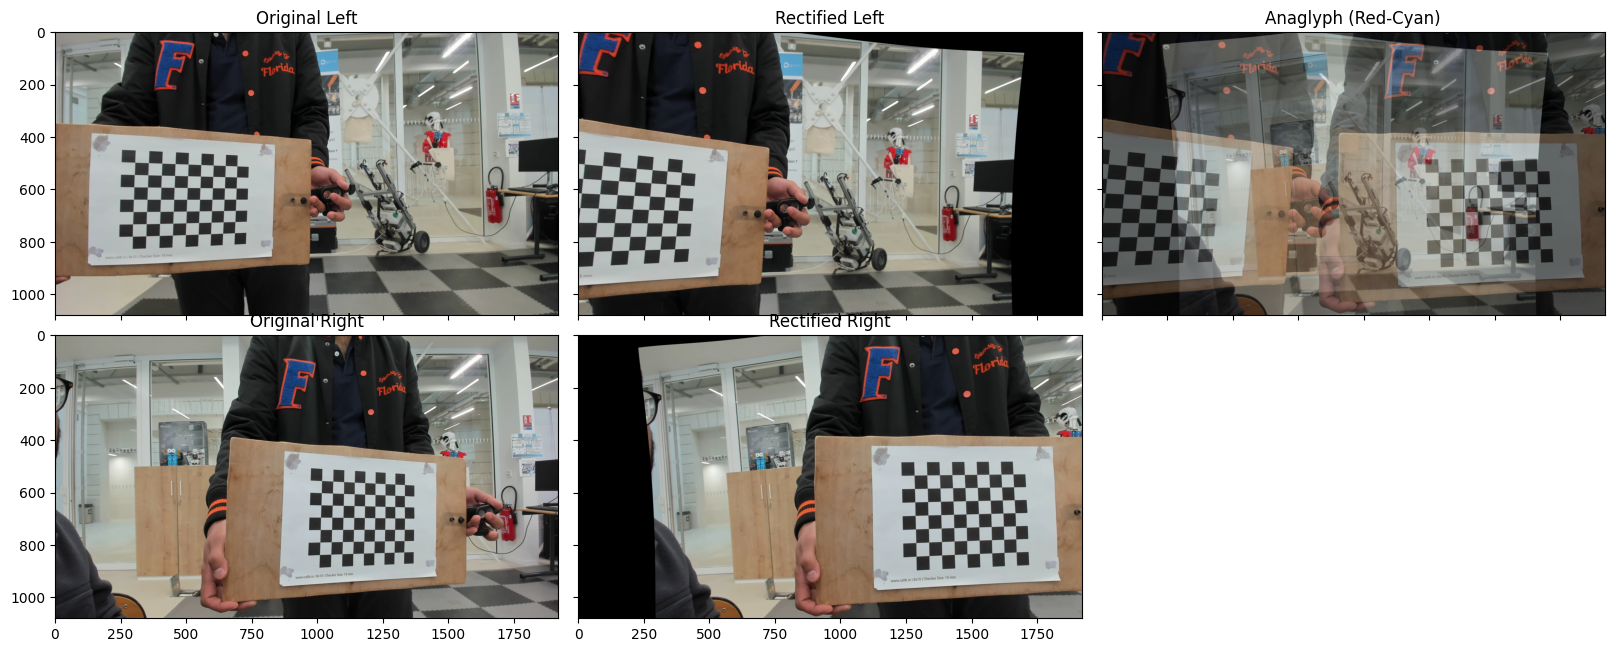

In [36]:
### STEP 10. =============== Rectification Visualization ====================
# Visualize the rectification results
# This step verifies the rectification results
# The rectification results are visualized using anaglyph
# The rectification results are visualized using side-by-side images
# The rectification results are visualized using a combined image
# The rectification results are visualized using a grid
# Verify horizontal epipolar alignment

# Rectify sample pair
rect_left = cv2.remap(img_left, left_map_x, left_map_y, cv2.INTER_LINEAR)
rect_right = cv2.remap(img_right, right_map_x, right_map_y, cv2.INTER_LINEAR)

# Create visualization grid
fig = plt.figure(figsize=(20, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(2, 3), axes_pad=0.2)

# Original images
grid[0].imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
grid[0].set_title("Original Left")
grid[3].imshow(cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB))
grid[3].set_title("Original Right")

# Rectified images
grid[1].imshow(cv2.cvtColor(rect_left, cv2.COLOR_BGR2RGB))
grid[1].set_title("Rectified Left")
grid[4].imshow(cv2.cvtColor(rect_right, cv2.COLOR_BGR2RGB))
grid[4].set_title("Rectified Right")

# Anaglyph visualization
anaglyph = cv2.addWeighted(rect_left, 0.5, rect_right, 0.5, 0)
grid[2].imshow(cv2.cvtColor(anaglyph, cv2.COLOR_BGR2RGB))
grid[2].set_title("Anaglyph (Red-Cyan)")
grid[5].axis('off')  # Spacer

plt.show()

In [37]:
### STEP 11. =============== Data Preservation ===================
# Save calibration parameters for 3D reconstruction

np.savez("stereo_calibration_parameters.npz",
         mtx_left=mtx_l, dist_left=dist_l,
         mtx_right=mtx_r, dist_right=dist_r,
         R=R, T=T, E=E, F=F,
         R1=R1, R2=R2, P1=P1, P2=P2, Q=Q,
         left_map_x=left_map_x, left_map_y=left_map_y,
         right_map_x=right_map_x, right_map_y=right_map_y,
         roi1=roi1, roi2=roi2)


print("\n💾 Calibration data saved to stereo_calibration_parameters.npz")

# ============================== SAVED PARAMETERS ==============================

# ➤ Intrinsic Parameters (mtx_left, mtx_right):
# - 3x3 camera matrix for each camera
# - Contains focal lengths (fx, fy), principal point (cx, cy)

# ➤ Distortion Coefficients (dist_left, dist_right):
# - Used to undistort images from lens warping (radial/tangential distortion)

# ➤ R (Rotation Matrix):
# - 3x3 matrix describing the rotation from left camera to right camera

# ➤ T (Translation Vector):
# - 3x1 vector describing the translation from left to right camera

# ➤ E (Essential Matrix):
# - Encodes R and T, used for epipolar geometry (e.g. 5-point algorithm)

# ➤ F (Fundamental Matrix):
# - Similar to E, but uses pixel coordinates. Used in stereo matching.

# ➤ R1, R2 (Rectification Transforms):
# - Rotation matrices to align both cameras to a common plane

# ➤ P1, P2 (Projection Matrices):
# - Used to project 3D world points into rectified image coordinates

# ➤ Q (Disparity-to-Depth Reprojection Matrix):
# - Used to convert disparity values into real-world (X, Y, Z) coordinates

# ➤ left_map_x/y, right_map_x/y:
# - Remapping matrices for cv2.remap() to rectify the stereo images

# # ➤ roi1 & roi2:
# - Region of the image that are reliable after rectification — no black invalid borders.

# Saving these lets you use rectification and point cloud generation without recalibrating each time.



💾 Calibration data saved to stereo_calibration_parameters.npz
